## **Very Basic but end to end ML project**
This project is only for understanding the Flow machine learning Proejct.

So here we perform **7 steps:**
1. Preprocess + EDA + Feature Selection
2. Extract input and output cols
3. Scale the values
4. Train Test Split
5. Train the Model
6. Evaluate the Model
7. Deploy Model

In [11]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('docs/lecture-002-placement.csv')

In [13]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [14]:
df.shape

(100, 4)

### **1. Preprocessing + Feature Selection**

In [17]:
df = df[["cgpa",	"iq",	"placement"]]

In [18]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


### **2. EDA**

In [19]:
import matplotlib.pyplot as plt


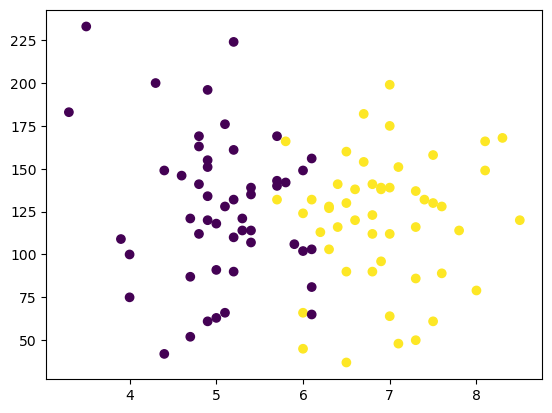

In [24]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

### **2. Input and output cols**

In [25]:
X = df.iloc[:,0:2] # first two cols
y = df.iloc[:,-1] # last 1 col

In [26]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [27]:
y.shape

(100,)

### **3. Test Train Split**

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.1)

In [32]:
X_train

,cgpa,iq
91,7.5,158.0
78,6.1,81.0
50,3.5,233.0
28,5.2,90.0
64,7.0,64.0
...,...,...
52,7.0,175.0
77,7.3,50.0
86,5.1,128.0
37,8.1,149.0


In [33]:
y_train

91    1
78    0
50    0
28    0
64    1
     ..
52    1
77    1
86    0
37    1
85    1
Name: placement, Length: 90, dtype: int64

In [34]:
X_test

,cgpa,iq
48,6.6,138.0
13,6.4,116.0
49,5.4,135.0
83,7.5,130.0
35,6.8,90.0
90,7.3,86.0
38,6.5,160.0
63,6.3,128.0
15,5.1,176.0
51,4.8,141.0


### **4. Scale the values**

In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
scaler = StandardScaler()

In [37]:
X_train = scaler.fit_transform(X_train)

In [38]:
X_train

array([[ 1.32653507,  0.85904707],
       [ 0.1205941 , -1.02368418],
       [-2.11901057,  2.69287622],
       [-0.65465367, -0.80362468],
       [ 0.89584187, -1.43935212],
       [ 0.63742594,  0.76124285],
       [ 1.15425779,  0.34557491],
       [-1.3437628 ,  0.63898758],
       [-0.56851503, -0.04564197],
       [ 0.1205941 ,  0.81014496],
       [ 0.37901002,  0.44337914],
       [ 0.03445546,  0.0277112 ],
       [ 0.80970322,  0.37002597],
       [ 2.0156442 ,  1.10355763],
       [-0.65465367, -0.31460358],
       [ 1.41267371, -0.82807574],
       [-1.08534688, -0.87697785],
       [ 0.89584187,  1.86154034],
       [-0.22396047,  1.12800868],
       [ 1.84336691,  1.05465552],
       [-0.91306959,  0.78569391],
       [-1.68831736, -0.55911413],
       [-0.22396047,  0.41892808],
       [ 0.20673274, -0.24125041],
       [ 0.5512873 , -0.07009303],
       [-0.74079231, -1.39045001],
       [ 0.89584187,  0.39447702],
       [-0.65465367,  0.22331964],
       [ 1.58495099,

In [39]:
X_test = scaler.transform(X_test)

In [40]:
X_test

array([[ 0.5512873 ,  0.37002597],
       [ 0.37901002, -0.16789725],
       [-0.48237639,  0.2966728 ],
       [ 1.32653507,  0.17441753],
       [ 0.72356458, -0.80362468],
       [ 1.15425779, -0.9014289 ],
       [ 0.46514866,  0.90794918],
       [ 0.29287138,  0.12551542],
       [-0.74079231,  1.29916607],
       [-0.99920823,  0.44337914]])

### **5. Train the Model**

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
clf = LogisticRegression()

In [43]:
# model training
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [44]:
y_pred = clf.predict(X_test)

In [45]:
y_test

48    1
13    1
49    0
83    1
35    1
90    1
38    1
63    1
15    0
51    0
Name: placement, dtype: int64

### **6. Evaluate the Model**

In [54]:
from sklearn.metrics import accuracy_score

In [55]:
accuracy_score(y_test,y_pred)

1.0

In [60]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

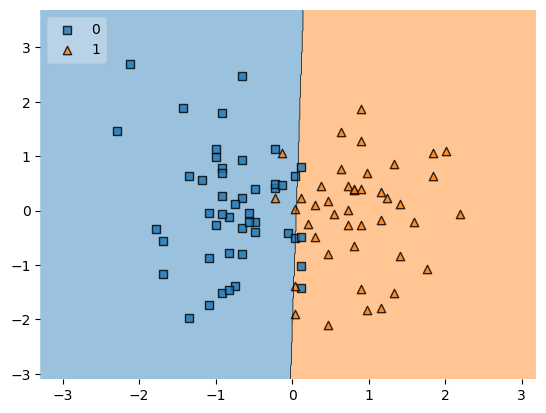

In [61]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [62]:
import pickle

In [63]:
pickle.dump(clf,open('model.pkl','wb'))